In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML library for Linear Regression, Ridge
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:
# data

df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# X and y
X = df[['total_bill']]
y = df['tip']


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((195, 1), (49, 1), (195,), (49,))

In [ ]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
# predict
y_pred = lr.predict(X_test)
y_pred[:5]

array([3.04525623, 1.86330727, 3.55119456, 3.69452593, 2.31576375])

In [ ]:
y_test[:5]

,tip
24,3.18
6,2.00
153,2.00
211,5.16
198,2.00


In [ ]:
# Metrics
print('MSE:', mean_squared_error(y_test, y_pred))
print('R2:', r2_score(y_test, y_pred))

MSE: 0.5688142529229536
R2: 0.5449381659234664


In [ ]:
# Coefficients
print('Coefficient:', lr.coef_)
print('Intercept:', lr.intercept_)
print("Equation of line: y =",lr.coef_,"*x + ",lr.intercept_)

Coefficient: [0.10696371]
Intercept: 0.925235558557056
Equation of line: y = [0.10696371] *x +  0.925235558557056


## Ridge Regression

In [ ]:
ridge = Ridge(alpha = 1000)
ridge.fit(X_train, y_train)

Ridge(alpha=1000)

In [ ]:
# predictions
y_pred = ridge.predict(X_test)
y_pred[:5]

array([3.04792778, 1.9402087 , 3.5220917 , 3.65642143, 2.36424958])

In [ ]:
# Metrics
print('MSE:', mean_squared_error(y_test, y_pred))
print('R2:', r2_score(y_test, y_pred))

MSE: 0.5638609618522789
R2: 0.5489008896206196


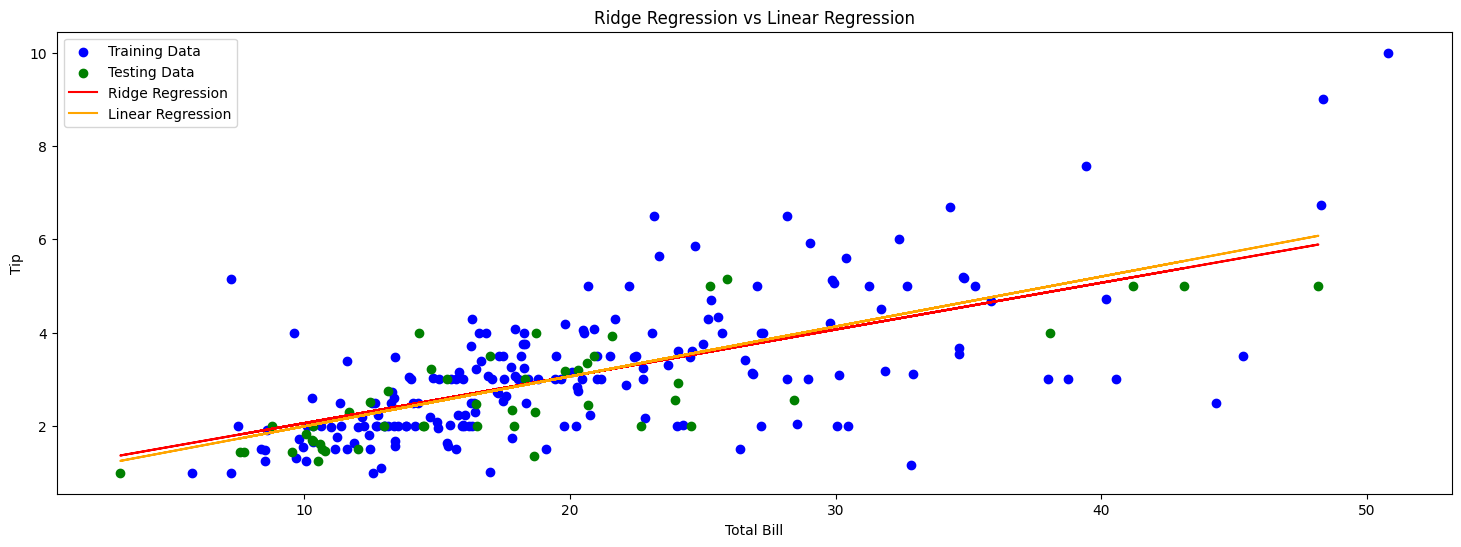

In [ ]:
# plot both Ridge and Linear Regression together
plt.figure(figsize=(18, 6))

plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.scatter(X_test, y_test, color='green', label='Testing Data')

plt.plot(X_test, y_pred, color='red', label='Ridge Regression')
plt.plot(X_test, lr.predict(X_test), color='orange', label='Linear Regression')

plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Ridge Regression vs Linear Regression')
plt.legend()
plt.show()

In [ ]:
# Line equation for Ridge

print("Coefficient of Ridge:", ridge.coef_)
print("Intercept of Ridge:", ridge.intercept_)
print("Equation of line: y =",ridge.coef_,"*x + ",ridge.intercept_)


Coefficient of Ridge: [0.10024607]
Intercept of Ridge: 1.0610506565865507
Equation of line: y = [0.10024607] *x +  1.0610506565865507


$$ \text{Ridge Objective} = \min \left[ \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} \beta_j^2 \right] $$



In [ ]:
# load the hitters data
df = pd.read_csv('/content/Hitters.csv')
df.head()

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Andy Allanson,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [ ]:
# data cleaning
df.isnull().sum()

,0
Unnamed: 0,0
AtBat,0
Hits,0
HmRun,0
Runs,0
RBI,0
Walks,0
Years,0
CAtBat,0
CHits,0


In [ ]:
# NUMERICAL AND CATEGORICAL COLUMNS
cat_cols = df.select_dtypes('object')
cat_cols

,Unnamed: 0,League,Division,NewLeague
0,-Andy Allanson,A,E,A
1,-Alan Ashby,N,W,N
2,-Alvin Davis,A,W,A
3,-Andre Dawson,N,E,N
4,-Andres Galarraga,N,E,N
...,...,...,...,...
317,-Willie McGee,N,E,N
318,-Willie Randolph,A,E,A
319,-Wayne Tolleson,A,W,A
320,-Willie Upshaw,A,E,A


In [ ]:
# find number of unique
cat_cols.nunique()

,0
Unnamed: 0,322
League,2
Division,2
NewLeague,2


In [ ]:
#  drop Unnamed: 0 column
cat_cols.drop(columns= ['Unnamed: 0'], inplace=True)

In [ ]:
# one - hot encoding
cat_cols = pd.get_dummies(cat_cols, dtype='int')
cat_cols

,League_A,League_N,Division_E,Division_W,NewLeague_A,NewLeague_N
0,1,0,1,0,1,0
1,0,1,0,1,0,1
2,1,0,0,1,1,0
3,0,1,1,0,0,1
4,0,1,1,0,0,1
...,...,...,...,...,...,...
317,0,1,1,0,0,1
318,1,0,1,0,1,0
319,1,0,0,1,1,0
320,1,0,1,0,1,0


In [ ]:
df.head()

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Andy Allanson,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [ ]:
# drop all categorical columns from df
df.drop(columns = ['Unnamed: 0', 'League', 'Division', 'NewLeague'], inplace=True)
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
0,293,66,1,30,29,14,1,293,66,1,30,29,14,446,33,20,NaN
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5


In [ ]:
# add cat_cols to df
df = pd.concat([df, cat_cols], axis=1)
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_A,League_N,Division_E,Division_W,NewLeague_A,NewLeague_N
0,293,66,1,30,29,14,1,293,66,1,30,29,14,446,33,20,NaN,1,0,1,0,1,0
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0,0,1,0,1,0,1
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0,1,0,0,1,1,0
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0,0,1,1,0,0,1
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5,0,1,1,0,0,1


In [ ]:
df.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_A,League_N,Division_E,Division_W,NewLeague_A,NewLeague_N
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882,0.543478,0.456522,0.487578,0.512422,0.546584,0.453416
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681,0.498881,0.498881,0.500624,0.500624,0.498600,0.498600
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# X and y
y = df['Salary']
X = df.drop(columns=['Salary'])


In [ ]:
# Standardize the X
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)



In [ ]:
# convert X to a df
X = pd.DataFrame(X, columns=df.columns[:-1])
X.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_A,League_N,Division_E,Division_W,NewLeague_A
0,-0.574071,-0.755130,-1.123591,-0.804734,-0.728308,-1.145172,-1.310194,-1.015121,-0.997117,-0.795183,-0.985636,-0.905069,-0.923478,0.560399,-0.540924,1.880899,0.916515,-0.916515,1.025161,-1.025161,0.910794,-0.910794
1,-0.430437,-0.431732,-0.433579,-1.035649,-0.383827,0.011930,1.332925,0.344876,0.179704,-0.005697,-0.113299,0.252124,0.430391,1.224048,-0.467740,0.308192,-1.091089,1.091089,-0.975456,0.975456,-1.097943,1.097943
2,0.640293,0.624699,0.831443,0.580752,0.917547,1.724442,-0.903560,-0.441561,-0.398759,-0.075357,-0.404078,-0.192719,0.010354,2.108915,-0.182323,0.937275,0.916515,-0.916515,-0.975456,0.975456,0.910794,-0.910794
3,0.751283,0.861858,1.061447,0.542266,1.147201,-0.080638,0.722974,1.283860,1.312145,1.805477,1.406546,1.526538,0.351634,-0.317331,-0.701928,-0.792703,-1.091089,1.091089,1.025161,-1.025161,-1.097943,1.097943
4,-0.391264,-0.302373,-0.088573,-0.458363,-0.230724,-0.404626,-1.106877,-0.970736,-0.943555,-0.667472,-0.931677,-0.853972,-0.852222,1.841314,-0.489695,-0.635432,-1.091089,1.091089,1.025161,-1.025161,-1.097943,1.097943


In [ ]:
X.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_A,League_N,Division_E,Division_W,NewLeague_A
count,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00,322.00
mean,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.38,-2.16,-1.24,-1.96,-1.84,-1.79,-1.31,-1.13,-1.09,-0.81,-1.07,-0.99,-0.98,-1.03,-0.78,-1.26,-1.09,-0.92,-0.98,-1.03,-1.10,-0.91
25%,-0.82,-0.80,-0.78,-0.80,-0.77,-0.77,-0.70,-0.79,-0.78,-0.64,-0.78,-0.73,-0.72,-0.64,-0.73,-0.79,-1.09,-0.92,-0.98,-1.03,-1.10,-0.91
50%,-0.01,-0.11,-0.32,-0.11,-0.15,-0.17,-0.29,-0.31,-0.32,-0.37,-0.34,-0.33,-0.34,-0.27,-0.49,-0.32,0.92,-0.92,-0.98,0.98,0.91,-0.91
75%,0.86,0.78,0.60,0.70,0.64,0.66,0.72,0.55,0.52,0.24,0.50,0.29,0.30,0.13,0.43,0.47,0.92,1.09,1.03,0.98,0.91,1.10
max,2.00,2.95,3.36,3.04,2.79,3.07,3.37,4.91,5.41,5.56,5.41,3.99,4.90,3.89,2.82,3.77,0.92,1.09,1.03,0.98,0.91,1.10


In [ ]:
# y - Missing data
y.fillna(y.median(), inplace=True)
y.isnull().sum()

np.int64(0)

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((257, 22), (65, 22), (257,), (65,))

### Multiple Linear Regression

In [ ]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)

LinearRegression()

In [ ]:
# y-pred
y_pred = mlr.predict(X_test)
y_pred[:5]

array([ 316.07121096,  845.92279165,  310.23483572,  647.03607922,
       1116.78772571])

In [ ]:
# metrics
print('MSE:', mean_squared_error(y_test, y_pred))
print('R2:', r2_score(y_test, y_pred))

MSE: 129139.98578201639
R2: 0.3279732368670133


# Lasso

In [ ]:
from sklearn.linear_model import Lasso



In [ ]:
lasso = Lasso(alpha=1.0,max_iter=1000)
lasso.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.966e+03, tolerance: 4.133e+03
  model = cd_fast.enet_coordinate_descent(


Lasso()

In [ ]:
y_pred_lasso = lasso.predict(X_test)
y_pred_lasso[:5]

array([ 319.02910626,  789.07483663,  312.1084677 ,  655.98499405,
       1047.90779908])

In [ ]:
# metrics
print('MSE:', mean_squared_error(y_test, y_pred_lasso))
print('R2:', r2_score(y_test, y_pred_lasso))

MSE: 123688.91331255296
R2: 0.35633986990536815


In [ ]:
# inspection of coefficients
print('Coefficient:', lasso.coef_)
print('Intercept:', lasso.intercept_)

Coefficient: [-2.88846192e+02  2.46284831e+02  2.56794626e+01 -0.00000000e+00
 -9.17789272e+00  1.08231054e+02 -6.23666180e+01 -2.66800435e+02
  2.20993495e+02  0.00000000e+00  2.36193325e+02  2.39117346e+02
 -1.96485691e+02  4.45089717e+01  3.67281542e+01 -1.46104662e+01
 -1.57908596e+01  4.41967304e-16  5.15208227e+01 -1.01276528e-13
  3.59062697e+00 -4.41469071e-15]
Intercept: 512.261328031345


In [ ]:
# feature_names
features = X.columns
print('Feature names:', features.tolist())

coefficients = pd.Series(lasso.coef_, index=features)
coefficients

Feature names: ['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors', 'Salary', 'League_A', 'League_N', 'Division_E', 'Division_W', 'NewLeague_A']


,0
AtBat,-288.85
Hits,246.28
HmRun,25.68
Runs,-0.00
RBI,-9.18
Walks,108.23
Years,-62.37
CAtBat,-266.80
CHits,220.99
CHmRun,0.00


## Observation of Lasso Coefficients

The Lasso regression model applies L1 regularization, which has the effect of shrinking some coefficients exactly to zero, thus performing feature selection. From the coefficients displayed above, we can observe the following:

*   **Features with Zero Coefficients:** 'Runs', 'CHmRun', 'League_A', 'Division_E', and 'NewLeague_A' have coefficients very close to or exactly zero. This indicates that the Lasso model has effectively removed these features from the prediction, suggesting they contribute little to predicting 'Salary' after regularization, or that their information is redundant with other features.

*   **Most Influential Features:** Features like 'AtBat', 'Hits', 'CAtBat', 'CHits', 'CRuns', 'CRBI', and 'CWalks' still have significant non-zero coefficients. These are the most influential predictors of 'Salary' according to this Lasso model.

*   **Interpretation of Magnitudes:** The magnitude of the non-zero coefficients indicates the strength of their relationship with 'Salary'. For example, 'AtBat' has a large negative coefficient, while 'Hits' and 'CRBI' have large positive coefficients, suggesting their strong inverse and direct relationships, respectively, with 'Salary' when other factors are held constant.

Lasso's ability to zero out coefficients makes it particularly useful for models with many features where feature selection is desired.

## Ridge

In [ ]:
from sklearn.linear_model import Ridge


ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

Ridge()

In [ ]:
y_pred_ridge = ridge.predict(X_test)
y_pred_ridge[:5]

array([ 319.61110938,  784.14944629,  311.38525468,  651.74019218,
       1051.31444617])

In [ ]:
# metrics
print('MSE:', mean_squared_error(y_test, y_pred_ridge))
print('R2:', r2_score(y_test, y_pred_ridge))

MSE: 124474.21981857519
R2: 0.35225324262169944


In [ ]:
# coefficinets
print('Coefficient:', ridge.coef_)
print('Intercept:', ridge.intercept_)

Coefficient: [-288.63604235  259.20733532   38.1879006   -14.12372142  -26.2047303
  115.64395111  -68.60549517 -258.65275353  238.64072603   13.24967042
  231.54935817  220.38296272 -205.83530764   45.09642834   40.2494625
  -18.18390576  -12.4243761    12.4243761    26.5504964   -26.5504964
    6.53650326   -6.53650326]
Intercept: 512.0276516353857


In [ ]:
# pandas series for features and coefficents

# feature_names
features = X.columns
print('Feature names:', features.tolist())

coefficients = pd.Series(ridge.coef_, index=features)
coefficients

Feature names: ['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors', 'Salary', 'League_A', 'League_N', 'Division_E', 'Division_W', 'NewLeague_A']


,0
AtBat,-288.64
Hits,259.21
HmRun,38.19
Runs,-14.12
RBI,-26.20
Walks,115.64
Years,-68.61
CAtBat,-258.65
CHits,238.64
CHmRun,13.25


## Observation of Ridge Coefficients

The Ridge regression model applies L2 regularization, which shrinks coefficients towards zero but typically does not set them exactly to zero, unlike Lasso regression. From the coefficients displayed for Ridge regression, we can observe the following:

*   **All Coefficients are Non-Zero:** Unlike Lasso, where some coefficients were explicitly set to zero, Ridge regression keeps all feature coefficients non-zero, although their magnitudes are reduced. This means Ridge tends to retain all features in the model, just reducing their impact.

*   **Impact on Feature Magnitudes:** Features that might have had a very high impact in a standard Linear Regression model will have their coefficients shrunk by Ridge regularization. For example, compare the magnitudes of the coefficients from Ridge regression (`coefficients`) to those of Lasso. While some coefficients are still relatively large (e.g., 'AtBat', 'Hits', 'CAtBat'), their absolute values are generally smaller than what they might be without regularization.

*   **Handling Multicollinearity:** Ridge regression is particularly effective when dealing with multicollinearity (highly correlated predictor variables). It distributes the impact among correlated features rather than selecting just one, as Lasso might do. Here, all features contribute to the prediction of 'Salary', albeit with reduced weights.

*   **Differences from Lasso:**
    *   **Feature Selection:** Lasso performs implicit feature selection by driving some coefficients to zero. Ridge does not perform feature selection; it only shrinks coefficients.
    *   **Coefficient Values:** While both reduce coefficient magnitudes, Lasso can be more aggressive in setting coefficients to zero, especially for less important features or in the presence of highly correlated features where it might pick one and zero out the others. Ridge, in contrast, will spread the impact across correlated features.

In summary, Ridge regression aims to improve the generalization of the model by preventing overfitting due to overly large coefficients, without discarding any features entirely.

In [ ]:
# plot